# ALeRCE LSST + ZTF queries

```Author: Alejandra Muñoz Arancibia. Last updated: 260825```

This notebook shows how to query both Rubin and ZTF alert stream data (as well as derived properties) stored by the ALeRCE broker. We show examples of queries to our databases tables via the ALeRCE python client (including alert image cutouts, hereafter "stamps") and Astronomical Data Query Language (ADQL) queries to the ALeRCE Table Access Protocol (TAP) service. We use the pandas package to manipulate output tables as dataframes.

We refer to [this notebook](https://github.com/alercebroker/usecases/tree/master/notebooks/LSST/ALeRCE_LSST_Tables.ipynb) for a detailed description of how Rubin data are stored in the ALeRCE multistream database. The ALeRCE python client is described in more detail in [this notebook](https://github.com/alercebroker/usecases/tree/master/notebooks/LSST/ALeRCE_LSST_Client_Queries.ipynb), while TAP queries (including advanced ones not yet available for the python client) are described in detail in [this notebook](https://github.com/alercebroker/usecases/tree/master/notebooks/LSST/ALeRCE_LSST_TAP_Queries.ipynb).

*It is highly recommended that you try this notebook in Google Colab using the following [link](https://colab.research.google.com/github/alercebroker/usecases/blob/master/notebooks/LSST/ALeRCE_LSST_ZTF.ipynb).* This will avoid you from having to sort out library installation problems and focus on the contents of the tutorial. You can try installing the dependencies later in your own system.

# Table of contents

* [Before starting](#before)
    * [Some settings](#settings)
    * [Initialize the ALeRCE client](#client)
    * [Connect to ALeRCE data via TAP](#tap)
    * [LSST queries to the ALeRCE multisurvey database](#multisurvey)
    * [Types of object identifiers](#sid)
* [How to query LSST and ZTF data for a given object](#query_one_lsst_ztf)
    * [Generate ALeRCE Explorer links](#explorer_url)
    * [Light curves](#light_curves)
    * [LSST stamps](#stamps_lsst)
    * [ZTF stamps](#stamps_ztf)
    * [Features](#features)

## Before starting <a class='anchor' id='before'></a>

### Some settings <a class='anchor' id='settings'></a>

Install the [ALeRCE python client](https://alerce.readthedocs.io/en/latest/) uncommenting the following line. In case you have a previous alerce package version, note that you need to update it to version 2.2.1 or newer to retrieve Rubin data.

In [1]:
#!pip install alerce

We also use custom functions defined in ```lib_multisurvey```. In case you are using Google Colab, download this uncommenting the following line.

In [2]:
#!wget https://raw.githubusercontent.com/alercebroker/usecases/master/notebooks/LSST/lib_multisurvey/alerce_multisurvey_tools.py -P lib_multisurvey/

Load libraries

In [3]:
#!pip install pyvo

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from astropy.cosmology import Planck18
import pyvo
import sys

In [5]:
from IPython.core.display import HTML
pd.set_option('display.max_colwidth', 1000)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 20)

In [6]:
from alerce.core import Alerce

### Initialize the ALeRCE client <a class='anchor' id='client'></a>

In [7]:
alerce_client = Alerce()

### Connect to ALeRCE data via TAP <a class='anchor' id='tap'></a>

We connect to ALeRCE databases using [ADQL](https://www.ivoa.net/documents/ADQL/) queries to the [ALeRCE TAP service](https://tap.alerce.online/), returning results as pandas dataframes. For the Rubin stream we use our multisurvey database, where table names are prefixed with `alerce_tap.` (e.g. `alerce_tap.object`, `alerce_tap.detection`, etc.); meanwhile, for the ZTF stream we currently use our legacy database, where tables are prefixed with `ztf.` (e.g. `ztf.object`, `ztf.detection`, etc.).

In [8]:
TAP_URL = 'https://tap.alerce.online/tap'
tap_service = pyvo.dal.TAPService(TAP_URL)

def tap_query(query, maxrec=10_000_000):
    result = tap_service.search(query, maxrec=maxrec)
    return result.to_table().to_pandas()

### LSST queries to the ALeRCE multisurvey database <a class='anchor' id='multisurvey'></a>

We save Rubin alert stream data in a multisurvey database. We distinguish among data sources by using the field ```tid```, for "telescope identifier". LSST (and more generally, all Rubin data observed with the Simonyi telescope) has ```tid = 1```.

In [9]:
tid = 1

### Types of object identifiers <a class='anchor' id='sid'></a>

In LSST alerts, astrophysical objects have different identifiers depending on what they are associated to. Non-moving objects (e.g. supernovae, active galactic nuclei, variable stars) are associated to diaObjects, while known Solar System moving objects (e.g. asteroids) are associated to ssObjects. Identifiers for diaObjects and ssObjects are generated independent of each other by the lsst pipelines. We distinguish among them using the field ```sid```, for "survey identifier".

We use the field ```oid``` as the identifier for each object. This ```oid``` is defined in different ways depending on the availability of diaObject information in the alert, so that

```oid = diaObjectId``` and ```sid = 1``` for objects that have diaObject information, and

```oid = ssObjectId``` and ```sid = 2``` if they only have ssObject information. In case an object has both identifiers (e.g. a known Solar System object was identified at a small angular distance from a non-moving object), we adopt ```oid = diaObjectId``` and ```sid = 1``` while still saving both their diaObject and ssObject data in the respective tables.

We call the identifier for each epoch in every survey as ```measurement_id```. For LSST, this means both field ```diaSourceId``` for detections and field ```diaForcedSourceId``` for forced photometry points are renamed ```measurement_id``` in our database. We also rename the mid-visit time for each epoch from field ```midpointMjdTai``` to ```mjd```.

## How to query LSST and ZTF data for a given object <a class='anchor' id='query_one_lsst_ztf'></a>

Here we illustrate a cone search, which is useful to explore LSST and ZTF data for an object from an external catalog whose equatorial coordinates are known. Along this example we show how to query several properties using TAP and the ALeRCE client, like basic statistics, light curves, and stamps.

Let us say we want to know if the known supernova [SN 2026asx](https://www.wis-tns.org/object/2026asx) has triggered Rubin and/or ZTF alerts. This object has equatorial coordinates (187.020186, 6.967836) deg, and was reported by ALeRCE to the [Transient Name Server](https://www.wis-tns.org/) based on ZTF detections. According to the TNS report, its host (LEDA 1311098) has redshift $z = 0.076$. We use a cone search with a small radius (e.g. 1.5 arcsec)

In [10]:
ra, dec = 187.020186, 6.967836
z_obj = 0.076
radius = 1.5

Note that you need to provide both object coordinates (equatorial system) and search radius in deg. If found, this query will return the main properties of the matching object

In [11]:
query = '''
SELECT
    *
FROM
    alerce_tap.object AS o
WHERE
    tid = %d
    AND CONTAINS(POINT('ICRS', o.meanra, o.meandec),
                 CIRCLE('ICRS', %.7g, %.7g, %g)) = 1
''' % (tid, ra, dec, radius / 3600.)

df_obj_lsst = tap_query(query)
display(df_obj_lsst)

,oid,tid,sid,meanra,meandec,sigmara,sigmadec,firstmjd,lastmjd,deltamjd,n_det,n_forced,n_non_det,created_date,updated_date
0,170028526513684557,1,1,187.020189,6.967839,1.239274e-07,1.276939e-07,61090.247937,61136.148496,45.900558,529,553,0,2026-02-20,2026-04-06


In [12]:
query = '''
SELECT
    *
FROM
    ztf.object AS o
WHERE
    CONTAINS(POINT('ICRS', o.meanra, o.meandec),
             CIRCLE('ICRS', %.7g, %.7g, %g)) = 1
''' % (ra, dec, radius / 3600.)

df_obj_ztf = tap_query(query)
display(df_obj_ztf)

,oid,ndethist,ncovhist,mjdstarthist,mjdendhist,corrected,stellar,ndet,g_r_max,g_r_max_corr,g_r_mean,g_r_mean_corr,meanra,meandec,sigmara,sigmadec,deltajd,firstmjd,lastmjd,step_id_corr,diffpos,reference_change
0,ZTF26aacextk,23,2217,61058.43963,61078.519271,False,False,6,NaN,NaN,NaN,NaN,187.020241,6.967839,0.030032,0.02981,18.958461,61059.56081,61078.519271,27.5.7a32.dev1,True,False


Now that we know the object identifiers in LSST and ZTF we can query its detections in each survey. For LSST we use its ```sid``` from the output table, while for ZTF we use ```sid = 0```

In [13]:
oid_lsst = df_obj_lsst.loc[0, 'oid'] if len(df_obj_lsst) > 0 else None
sid_lsst = df_obj_lsst.loc[0, 'sid'] if len(df_obj_lsst) > 0 else None
print('LSST', oid_lsst, sid_lsst)

LSST 170028526513684557 1


In [14]:
oid_ztf = df_obj_ztf.loc[0, 'oid'] if len(df_obj_ztf) > 0 else None
sid_ztf = 0 if len(df_obj_ztf) > 0 else None
print('ZTF', oid_ztf, sid_ztf)

ZTF ZTF26aacextk 0


### Generate ALeRCE Explorer links <a class='anchor' id='explorer_url'></a>

Note that the interfaces accept a maximum of 200 objects

In [15]:
def print_link_lsst(index=None, classifier='stamp_classifier_rubin_beta_20260421'):
    if len(index) == 1:
        expr = 'https://lsst.alerce.online/object/' + str(index[0]) \
               + '?survey=lsst'
    else:
        expr1 = 'https://lsst.alerce.online/?oid='
        expr2 = ','.join(list([str(x) for x in index]))
        expr3 = '&survey=lsst'
        expr4 = '&classifier=' + classifier + '&page=1'
        expr = expr1 + expr2 + expr3 + expr4
    
    display(HTML("<a href='%s' target=\"_blank\"> %s <a>" % (expr, expr)))

In [16]:
def print_link_ztf(index=None, classifier='stamp_classifier'):
    if len(index) == 1:
        expr = 'https://alerce.online/object/' + index[0]
    else:
        expr1 = 'https://alerce.online/?oid='
        expr2 = '&oid='.join(list(index))
        expr3 = '&selectedClassifier=' + classifier + '&page=1'
        expr = expr1 + expr2 + expr3
    
    display(HTML("<a href='%s' target=\"_blank\"> %s <a>" % (expr, expr)))

In [17]:
if oid_lsst is not None:
    print_link_lsst(index=[oid_lsst])

In [18]:
if oid_ztf is not None:
    print_link_ztf(index=[oid_ztf])

### Light curves <a class='anchor' id='light_curves'></a>

We obtain its light curve (detections and forced photometry points) by using the ```query_detections``` and ```query_forced_photometry ```functions

In [19]:
if oid_lsst is not None:
    df_dets_lsst = alerce_client.query_detections(
        oid_lsst,
        survey='lsst',
        format='pandas'
    )
    display(df_dets_lsst)

,band,mjd,survey_id,ra,dec,oid,measurement_id,parentDiaSourceId,diaObjectId,psfFlux,psfFluxErr,psfFlux_flag,psfFlux_flag_edge,psfFlux_flag_noGoodPixels,scienceFlux,scienceFluxErr,has_stamp,visit,detector,ssObjectId,raErr,decErr,ra_dec_Cov,x,xErr,y,yErr,centroid_flag,apFlux,apFluxErr,apFlux_flag,apFlux_flag_apertureTruncated,isNegative,snr,psfLnL,psfChi2,psfNdata,trailFlux,trailFluxErr,trailRa,trailRaErr,trailDec,trailDecErr,trailLength,trailLengthErr,trailAngle,trailAngleErr,trailChi2,trailNdata,trail_flag_edge,dipoleMeanFlux,dipoleMeanFluxErr,dipoleFluxDiff,dipoleFluxDiffErr,dipoleLength,dipoleAngle,dipoleChi2,dipoleNdata,forced_PsfFlux_flag,forced_PsfFlux_flag_edge,forced_PsfFlux_flag_noGoodPixels,templateFlux,templateFluxErr,ixx,iyy,ixy,ixxPSF,iyyPSF,ixyPSF,shape_flag,shape_flag_no_pixels,shape_flag_not_contained,shape_flag_parent_source,extendedness,reliability,isDipole,dipoleFitAttempted,timeProcessedMjdTai,timeWithdrawnMjdTai,bboxSize,pixelFlags,pixelFlags_bad,pixelFlags_cr,pixelFlags_crCenter,pixelFlags_edge,pixelFlags_nodata,pixelFlags_nodataCenter,pixelFlags_interpolated,pixelFlags_interpolatedCenter,pixelFlags_offimage,pixelFlags_saturated,pixelFlags_saturatedCenter,pixelFlags_suspect,pixelFlags_suspectCenter,pixelFlags_streak,pixelFlags_streakCenter,pixelFlags_injected,pixelFlags_injectedCenter,pixelFlags_injected_template,pixelFlags_injected_templateCenter,glint_trail,band_name
0,3,61090.247937,lsst,187.020188,6.967830,170028526513684557,170028526513684557,0,170028526513684557,28242.050,365.80746,0,0,0,75483.920,368.47670,False,2026021800360,145,NaN,0.000003,0.000003,-1.429093e-12,1327.68700,0.053634,2865.55760,0.062551,False,28883.625,685.58203,False,False,False,76.423260,None,1775.4773,1681,27233.220,0.699775,187.020189,None,6.967829,None,0.733123,None,114.661380,None,None,0,False,None,None,None,None,None,None,None,0,False,False,False,46383.430,23.967625,0.258646,0.304292,0.005605,0.265069,0.314855,0.003109,False,False,False,False,0.006199,0.999984,False,False,61090.249555,None,33,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,i
1,3,61090.248460,lsst,187.020186,6.967837,170028526513684557,170028526648426560,0,170028526513684557,28295.225,378.44610,0,0,0,77013.450,380.54254,False,2026021800361,146,NaN,0.000004,0.000003,5.497801e-13,1304.35960,0.064978,2940.49830,0.061851,False,30203.986,692.92170,False,False,False,74.090126,None,1606.1893,1681,26824.934,0.011511,187.020187,None,6.967838,None,0.548408,None,103.760250,None,None,0,False,None,None,None,None,None,None,None,0,False,False,False,48106.562,18.704697,0.323573,0.324159,0.012824,0.321277,0.301220,0.005265,False,False,False,False,0.012710,0.999961,False,False,61090.250148,None,39,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,i
2,3,61090.248928,lsst,187.020187,6.967841,170028526513684557,170028526761672712,0,170028526513684557,29842.018,374.21810,0,0,0,76596.060,375.63130,False,2026021800362,106,NaN,0.000003,0.000003,2.398282e-13,1211.58670,0.059730,388.13254,0.058319,False,31890.660,689.67316,False,False,False,79.224450,None,1826.5992,1681,28082.600,0.376741,187.020187,None,6.967841,None,0.315864,None,98.725360,None,None,0,False,None,None,None,None,None,None,None,0,False,False,False,46111.094,23.524155,0.321203,0.320733,0.004183,0.313450,0.294817,0.003391,False,False,False,False,0.023009,0.999987,False,False,61090.250538,None,58,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,i
3,3,61090.249392,lsst,187.020190,6.967834,170028526513684557,170028526916337670,0,170028526513684557,28559.727,388.38940,0,0,0,80759.650,391.18463,False,2026021800363,145,NaN,0.000004,0.000004,-1.031545e-12,2570.11230,0.064965,299.62250,0.070066,False,30070.717,691.36880,False,False,False,72.395950,None,1588.3430,1681,26803.895,0.140040,187.020191,None,6

In [20]:
if oid_ztf is not None:
    df_dets_ztf = alerce_client.query_detections(
        oid_ztf,
        survey='ztf',
        format='pandas'
    )
    df_dets_ztf['oid'] = oid_ztf
    display(df_dets_ztf)

,tid,mjd,candid,fid,pid,diffmaglim,isdiffpos,nid,distnr,magpsf,magap,sigmapsf,sigmagap,ra,dec,rb,rbversion,drb,magapbig,sigmagapbig,rfid,has_stamp,corrected,dubious,step_id_corr,phase,parent_candid,magpsf_corr,sigmapsf_corr,sigmapsf_corr_ext,oid
0,ztf,61059.560810,3305560815515015025,1,3305560815515,20.492268,1,3305,1.491836,20.141708,20.1365,0.183754,0.2805,187.020236,6.967859,0.764286,t17_f5_c3,0.999971,20.1899,0.3743,473120155.0,True,False,False,27.5.7a32.dev1,0.0,NaN,NaN,NaN,NaN,ZTF26aacextk
1,ztf,61061.454224,3307454225515015023,1,3307454225515,20.578934,1,3307,1.715862,20.073265,20.1090,0.212786,0.2520,187.020232,6.967944,0.820000,t17_f5_c3,0.999997,20.0094,0.2916,473120155.0,True,False,False,27.5.7a32.dev1,0.0,NaN,NaN,NaN,NaN,ZTF26aacextk
2,ztf,61061.543889,3307543885515015017,2,3307543885515,19.945002,1,3307,4.528496,19.761988,19.4851,0.160267,0.2668,187.020187,6.967794,0.800000,t17_f5_c3,0.999894,19.4458,0.3278,473120255.0,True,False,False,27.5.7a32.dev1,0.0,NaN,NaN,NaN,NaN,ZTF26aacextk
3,ztf,61069.459850,3315459845515015013,2,3315459845515,19.763500,1,3315,4.357890,19.411000,19.3742,0.213132,0.2418,187.020296,6.967851,0.818571,t17_f5_c3,NaN,19.3053,0.2897,NaN,False,False,False,27.5.7a32.dev1,0.0,3.324519e+18,NaN,NaN,NaN,ZTF26aacextk
4,ztf,61069.508484,3315508485515015025,1,3315508485515,20.310700,1,3315,1.355290,19.838900,20.2155,0.237601,0.3167,187.020254,6.967780,0.755714,t17_f5_c3,NaN,20.4713,0.5091,NaN,False,True,True,27.5.7a32.dev1,0.0,3.324519e+18,19.182226,0.125228,0.129771,ZTF26aacextk
5,ztf,61078.519271,3324519275515015004,2,3324519275515,19.720327,1,3324,4.301351,19.594992,19.7324,0.179135,0.3838,187.020239,6.967757,0.795714,t17_f5_c3,0.999995,19.3882,0.3575,473120255.0,True,False,False,27.5.7a32.dev1,0.0,NaN,NaN,NaN,NaN,ZTF26aacextk


In [21]:
if oid_lsst is not None:
    df_forced_lsst = alerce_client.query_forced_photometry(
        oid_lsst,
        survey='lsst',
        format='pandas'
    )
    display(df_forced_lsst)

,band,mjd,survey_id,oid,measurement_id,ra,dec,visit,detector,psfFlux,psfFluxErr,scienceFlux,scienceFluxErr,band_name
0,3,61090.251692,lsst,170028526513684557,170028527590572038,187.020188,6.967832,2026021800368,151,29696.482,380.51282,75920.550,372.58075,i
1,3,61090.253555,lsst,170028526513684557,170028528126918666,187.020187,6.967834,2026021800372,150,29327.574,367.05490,72218.300,359.08206,i
2,3,61090.254021,lsst,170028526513684557,170028528260087818,187.020187,6.967834,2026021800373,148,28837.176,397.59920,78974.050,388.66570,i
3,3,61090.254487,lsst,170028526513684557,170028528389062677,187.020189,6.967834,2026021800374,138,28981.197,387.34332,77130.810,378.46716,i
4,1,61090.256338,lsst,170028526513684557,170028528506503186,187.020189,6.967835,2026021800375,106,10255.549,192.53212,31994.969,187.32994,g
5,1,61090.256792,lsst,170028526513684557,170028528661692422,187.020189,6.967836,2026021800376,146,10393.849,202.58733,33574.330,198.65761,g
6,1,61090.260023,lsst,170028526513684557,170028529603837963,187.020189,6.967838,2026021800383,151,9924.935,193.55040,30402.035,188.03040,g
7,1,61090.260489,lsst,170028526513684557,170028529735958538,187.020188,6.967838,2026021800384,147,9870.156,184.71591,28784.572,179.97740,g
8,1,61090.261884,lsst,170028526513684557,170028530140184596,187.020188,6.967837,2026021800387,150,9810.873,182.88115,28396.545,178.73892,g
9,1,61090.262818,lsst,170028526513684557,170028530402328626,187.020189,6.967839,2026021800389,138,9796.413,170.80965,26155.857,167.23721,g


In [22]:
if oid_ztf is not None:
    df_forced_ztf = alerce_client.query_forced_photometry(
        oid_ztf,
        survey='ztf',
        format='pandas'
    )
    display(df_forced_ztf)

,candid,tid,pid,oid,mjd,fid,ra,e_ra,dec,e_dec,mag,e_mag,mag_corr,e_mag_corr,e_mag_corr_ext,isdiffpos,corrected,dubious,parent_candid,has_stamp,rfid,clrcoeff,ranr,sciinpseeing,clrcounc,decnr,scibckgnd,exptime,magnr,scisigpix,adpctdif1,sigmagnr,magzpsci,adpctdif2,chinr,diffmaglim,programid,sharpnr,field,magzpsciunc,procstatus,rcid,magzpscirms,distnr
0,ZTF26aacextk3297488265515,ztf,3297488265515,ZTF26aacextk,61051.488264,1,187.020239,None,6.967757,None,22.482584,1.565787,None,None,None,1,False,False,3324519275515015004,False,473120155,-0.048836,187.019318,3.3359,0.000046,6.967804,143.070999,30.0,20.549,7.92209,0.147129,0.073,26.374201,0.121274,1.868,19.874001,1,0.180,473,0.000025,0,55,0.038131,3.303046
1,ZTF26aacextk3299442885515,ztf,3299442885515,ZTF26aacextk,61053.442882,1,187.020239,None,6.967757,None,23.390682,3.380716,None,None,None,1,False,False,3324519275515015004,False,473120155,-0.024065,187.019318,4.3818,0.000075,6.967804,138.923996,30.0,20.549,6.11406,0.156032,0.073,26.339600,0.137094,1.868,19.861099,1,0.180,473,0.000035,0,55,0.042637,3.303046
2,ZTF26aacextk3299488735515,ztf,3299488735515,ZTF26aacextk,61053.488738,2,187.020239,None,6.967757,None,24.185200,6.662045,None,None,None,1,False,False,3324519275515015004,False,473120255,0.114467,187.021210,3.0140,0.000023,6.967034,252.268997,30.0,17.954,6.93169,0.143160,0.080,26.270700,0.119535,5.745,20.000099,1,0.429,473,0.000014,0,55,0.031032,4.352313
3,ZTF26aacextk3301478315515,ztf,3301478315515,ZTF26aacextk,61055.478310,1,187.020239,None,6.967757,None,21.286034,0.368569,None,None,None,1,False,False,3324519275515015004,False,473120155,-0.036115,187.019318,2.8166,0.000030,6.967804,142.324997,30.0,20.549,5.90299,0.131190,0.073,26.357599,0.119541,1.868,20.302799,1,0.180,473,0.000018,0,55,0.034588,3.303046
4,ZTF26aacextk3301505015515,ztf,3301505015515,ZTF26aacextk,61055.505012,2,187.020239,None,6.967757,None,20.622768,0.266088,None,None,None,1,False,False,3324519275515015004,False,473120255,0.108330,187.021210,2.4862,0.000018,6.967034,251.244003,30.0,17.954,7.67798,0.128010,0.080,26.271400,0.115911,5.745,20.039900,1,0.429,473,0.000011,0,55,0.027144,4.352313
5,ZTF26aacextk3303455595515,ztf,3303455595515,ZTF26aacextk,61057.455590,1,187.020239,None,6.967757,None,21.039072,0.402680,None,None,None,1,False,False,3324519275515015004,False,473120155,-0.049244,187.019318,3.9540,0.000072,6.967804,132.537003,30.0,20.549,6.38985,0.148896,0.073,26.291201,0.131290,1.868,19.870300,1,0.180,473,0.000037,0,55,0.045327,3.303046
6,ZTF26aacextk3303473705515,ztf,3303473705515,ZTF26aacextk,61057.473704,2,187.020239,None,6.967757,None,20.034201,0.185645,None,None,None,1,False,False,3324519275515015004,False,473120255,0.107774,187.021210,3.6230,0.000034,6.967034,237.901001,30.0,17.954,7.03106,0.141765,0.080,26.209101,0.131090,5.745,19.780199,1,0.429,473,0.000021,0,55,0.037741,4.352313
7,ZTF26aacextk3305560815515,ztf,3305560815515,ZTF26aacextk,61059.560810,1,187.020239,None,6.967757,None,20.121248,0.104910,None,None,None,1,False,False,3324519275515015004,False,473120155,-0.057731,187.019318,2.0932,0.000019,6.967804,142.671005,30.0,20.549,6.42012,0.114288,0.073,26.372700,0.106641,1.868,20.492300,1,0.180,473,0.000012,0,55,0.028244,3.303046
8,ZTF26aacextk3307543885515,ztf,3307543885515,ZTF26aacextk,61061.543889,2,187.020239,None,6.967757,None,19.741327,0.121587,None,None,None,1,False,False,3324519275515015004,False,473120255,0.107220,187.021210,1.9805,0.000021,6.967034,199.630005,30.0,17.954,8.13969,0.123691,0.080,26.037001,0.111263,5.745,19.945000,1,0.429,473,0.000013,0,55,0.029394,4.352313
9,ZTF26aacextk3315459845515,ztf,3315459845515,ZTF26aacextk,61069.459850,2,187.020239,None,6.967757,None,19.495583,0.116162,None,None,None,1,False,False,3324519275515015004,False,473120255,0.111528,187.021210,2.5029,0.000028,6.967034,242.201996,30.0,17.954,9.63105,0.138968,0.080,26.229000,0.127353,5.745,19.763500,1,0.429,473,0.000018,0,55,0.034514,4.352313


We show these light curves together using a custom function defined in ```lib_multisurvey```

In [23]:
sys.path.append('./lib_multisurvey')
import alerce_multisurvey_tools as ms

We define some dictionaries to customize how to show the light curves. We will show both difference and science fluxes, including detections and (when available) forced photometry epochs 

In [24]:
# More parameters (and their default values) defined in
# lib_multisurvey/alerce_multisurvey_tools.py, function plot_lc
lc_params = {
    'use_mag': False,
    'use_flux': True,
    'show_yr': False,
    'figwidth': 8,
    'pheight': 3,
    'fontsize': 9,
    'alpha': 0.5,
}

In [25]:
if oid_lsst is not None:
    df_dets_lsst.set_index('oid', inplace=True)
    if len(df_forced_lsst) > 0:
        df_forced_lsst.set_index('oid', inplace=True)
    
    epochs_lsst = {
        'detections': df_dets_lsst,
        'forced_photometry': df_forced_lsst,
    }

For ZTF data, we obtain flux density measurements from magnitudes, and adapt the column that contains filter information to the input expected by the custom function

In [26]:
def flux_epochs_ztf(df=None, col_mag=None, col_magerr=None,
                    col_isdiffpos='isdiffpos'):
    df = df.copy()
    
    df['fluxdiff_nJy'] = ms.mag2fluxnjy(df[col_mag]) * df[col_isdiffpos]
    df['fluxdiff_err_nJy'] = ms.mag_err_2_fluxnjy_err(df[col_magerr], df[col_mag])
    
    if col_mag + '_corr' in df.columns:
        df['fluxsci_nJy'] = ms.mag2fluxnjy(df[col_mag + '_corr'])
        mask = ~df[col_magerr + '_corr_ext'].isna() & ~df[col_magerr + '_corr_ext'].isna()
        df.loc[mask, 'fluxsci_err_nJy'] = ms.mag_err_2_fluxnjy_err(df[col_magerr + '_corr_ext'], df[col_mag + '_corr'])
        df.loc[~mask, 'fluxsci_err_nJy'] = np.nan
    
    return df

In [27]:
if oid_ztf is not None:
    df_dets_ztf['band'] = [ms.sid_map_bands[sid_ztf][x] for x in df_dets_ztf['fid']]
    df_dets_ztf = flux_epochs_ztf(df_dets_ztf, col_mag='magpsf', col_magerr='sigmapsf')

In [28]:
if oid_ztf is not None:
    df_forced_ztf['band'] = [ms.sid_map_bands[sid_ztf][x] for x in df_forced_ztf['fid']]
    df_forced_ztf = flux_epochs_ztf(df_forced_ztf, col_mag='mag', col_magerr='e_mag')

In [29]:
if oid_ztf is not None:
    df_dets_ztf.set_index('oid', inplace=True)
    if len(df_forced_ztf) > 0:
        df_forced_ztf.set_index('oid', inplace=True)

    epochs_ztf = {
        'detections': df_dets_ztf,
        'forced_photometry': df_forced_ztf,
    }

In [30]:
d_objs = ms.group_data_sid_oid(
    sid=sid_lsst,
    oid=oid_lsst,
    df_dets=epochs_lsst['detections'].copy() \
        if oid_lsst is not None else pd.DataFrame(),
    df_forced=epochs_lsst['forced_photometry'].copy() \
        if oid_lsst is not None and oid_lsst in epochs_lsst['forced_photometry'].index \
        else pd.DataFrame(),
    lc_kwargs=ms.init_lc_kwargs()
)

In [31]:
d_objs = ms.group_data_sid_oid(
    d_objs=d_objs,
    sid=sid_ztf,
    oid=oid_ztf,
    df_dets=epochs_ztf['detections'].copy() \
        if oid_ztf is not None else pd.DataFrame(),
    df_forced=epochs_ztf['forced_photometry'].copy() \
        if oid_ztf is not None and oid_ztf in epochs_ztf['forced_photometry'].index \
        else pd.DataFrame(),
    lc_kwargs=ms.init_lc_kwargs()
)

We show the light curves

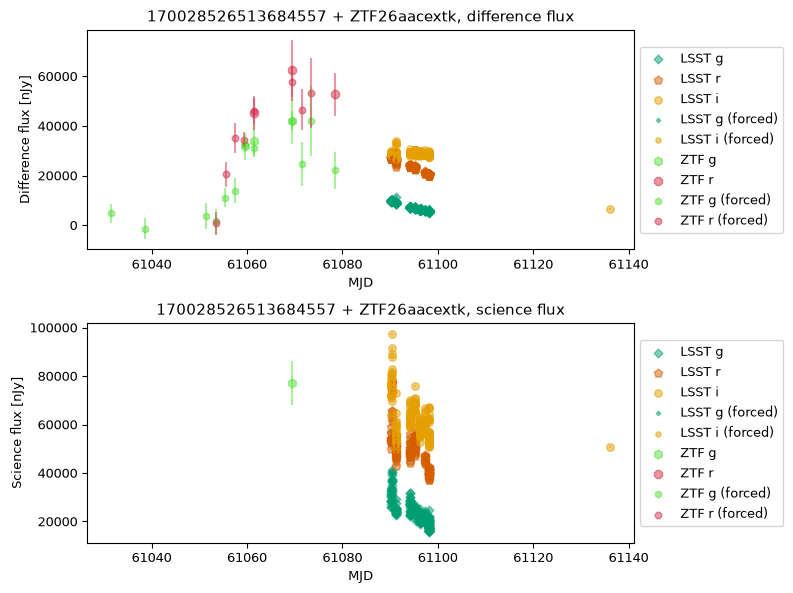

In [32]:
if oid_lsst is not None:
    d_objs[sid_lsst][oid_lsst]['lc_kwargs']['show_forced'] = True

if oid_ztf is not None:
    d_objs[sid_ztf][oid_ztf]['lc_kwargs']['show_forced'] = True

ms.plot_lc_1panel(d_objs=d_objs, lc_params=lc_params)

We can show these light curves using magnitude units

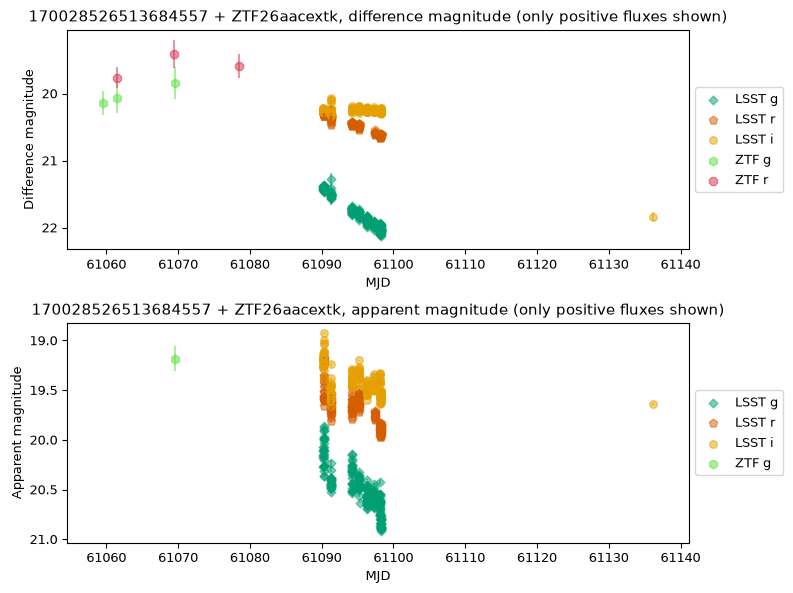

In [33]:
if oid_lsst is not None:
    d_objs[sid_lsst][oid_lsst]['lc_kwargs']['show_flux'] = False
    d_objs[sid_lsst][oid_lsst]['lc_kwargs']['show_forced'] = False

if oid_ztf is not None:
    d_objs[sid_ztf][oid_ztf]['lc_kwargs']['show_flux'] = False
    d_objs[sid_ztf][oid_ztf]['lc_kwargs']['show_forced'] = False

ms.plot_lc_1panel(d_objs=d_objs, lc_params=lc_params)

We can also show them using absolute magnitudes, assuming the redshift of the tentative host and the Planck 2018 cosmology

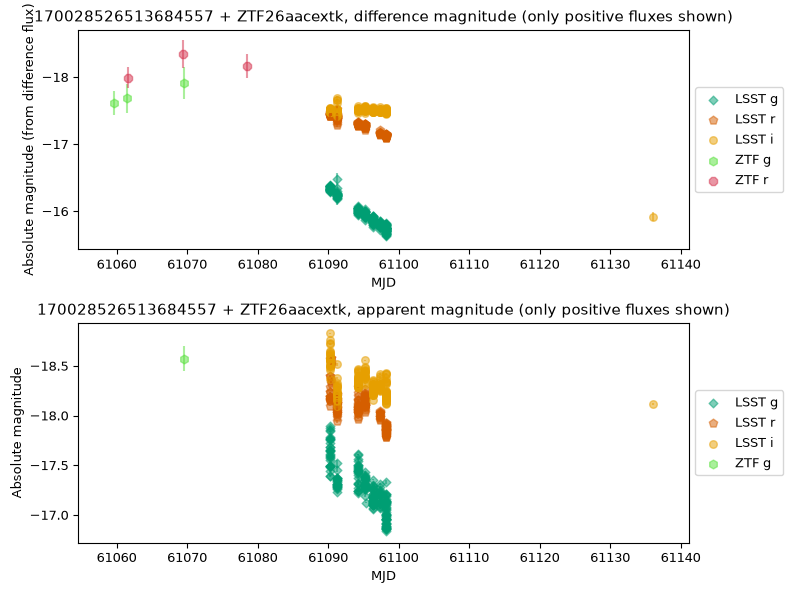

In [34]:
if oid_lsst is not None:
    d_objs[sid_lsst][oid_lsst]['lc_kwargs']['show_absolute_mag'] = True
    d_objs[sid_lsst][oid_lsst]['lc_kwargs']['z_obj'] = z_obj
    d_objs[sid_lsst][oid_lsst]['lc_kwargs']['cosmo'] = Planck18

if oid_ztf is not None:
    d_objs[sid_ztf][oid_ztf]['lc_kwargs']['show_absolute_mag'] = True
    d_objs[sid_ztf][oid_ztf]['lc_kwargs']['z_obj'] = z_obj
    d_objs[sid_ztf][oid_ztf]['lc_kwargs']['cosmo'] = Planck18

ms.plot_lc_1panel(d_objs=d_objs, lc_params=lc_params)

#### LSST stamps <a class='anchor' id='stamps_lsst'></a>

We show alert image cutouts for the first two detections of this object that LSST triggered alerts. Note that not all stored detections may have triggered an alert, as they may come in an alert as previous detections. The field ```has_stamp``` in our detections dataframe indicates that a given detection triggered an alert, so that we can use it as a mask as

In [35]:
if oid_lsst is not None:
    mask = epochs_lsst['detections']['has_stamp']
    df_dets_this = epochs_lsst['detections'][mask].sort_values(by='mjd').iloc[0:2].copy()

    cols = ['measurement_id', 'band_name', 'mjd',
            'psfFlux', 'psfFluxErr', 'scienceFlux', 'scienceFluxErr',
            'has_stamp']
    display(df_dets_this[cols])

,measurement_id,band_name,mjd,psfFlux,psfFluxErr,scienceFlux,scienceFluxErr,has_stamp
oid,,,,,,,,
170028526513684557,170032915984941093,i,61091.230601,28346.492,363.65262,59275.176,366.90543,True
170028526513684557,170032916102905904,i,61091.231068,28748.594,473.74792,55875.258,477.45096,True


We retrieve the stamps, obtaining the main fields: Science, Template and Difference

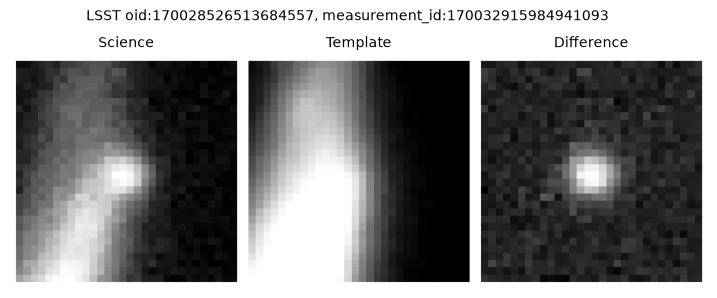

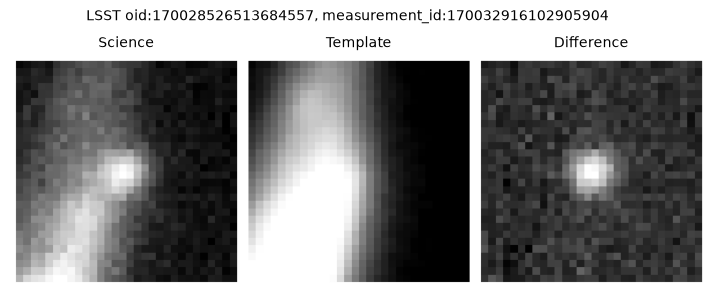

In [36]:
if oid_lsst is not None:
    for i, row in df_dets_this.iterrows():
        params = {
            'survey': 'lsst',
            'oid': i,
            'measurement_id': row['measurement_id'],
        }
        df_stamps = alerce_client.plot_stamps(**params)

We show the same stamps, but using a custom function defined in ```alerce_multisurvey_tools.py```. This requires querying the stamps using the client function ```get_stamps```, that also retrieves the stamps headers

In [37]:
fontsize = 8

In [38]:
def set_title(oid=None, sid=None, row=None):
    title = ms.sid_num2str[sid] + ', oid=' + str(oid) 

    if sid == 0:
        col_brightness = 'magpsf'
        col_brightness_err = 'sigmapsf'
        title += ', ' \
            + 'candid=' + str(row['candid']) + '\n' \
            + 'band=' + row['band'] + ', ' \
            + 'mjd=%.4f' % row['mjd'] + ', ' \
            + 'mag=%.2f' % row[col_brightness] + '+-' \
            + '%.2f' % row[col_brightness_err]
    else:
        col_brightness = 'psfFlux'
        col_brightness_err = 'psfFluxErr'
        title += ', ' \
            + 'measurement_id=' + str(row['measurement_id']) + '\n' \
            + 'band=' + row['band_name'] + ', ' \
            + 'mjd=%.4f' % row['mjd'] + ', ' \
            + 'S/N=%.2f' % row['snr'] + ', ' \
            + 'psfFlux=%.f' % row[col_brightness] + '+-' \
            + '%.f uJy' % row[col_brightness_err]

    return title

In [39]:
if oid_lsst is not None:
    df_stamps = ms.query_stamps(client=alerce_client, df_objs=df_dets_this,
                                survey='lsst', sid=sid_lsst)
    print(df_stamps.columns)

Index(['measurement_id', 'flux_Science_data', 'flux_Science_header',
       'flux_Template_data', 'flux_Template_header', 'flux_Difference_data',
       'flux_Difference_header'],
      dtype='object')


We show how this table looks like for the first detection

In [40]:
if oid_lsst is not None:
    display(df_stamps.iloc[[0]])

,measurement_id,flux_Science_data,flux_Science_header,flux_Template_data,flux_Template_header,flux_Difference_data,flux_Difference_header
oid,,,,,,,
170028526513684557,170032915984941093,"[[28.478943, 41.04594, 114.41765, 162.28958, 194.57689, 138.78429, 242.99185, 259.14328, 293.0225, 329.9967, 346.5124, 335.235, 329.04196, 243.68591, 209.71626, 179.82474, 126.798096, 113.99408, 12.771317, 64.41752, 77.213356, 23.723087, 50.812172, 27.457994, -51.653854, 53.010677, -65.4196, 2.549035, -2.0106096, 44.507587], [136.42406, 111.640625, 100.46574, 117.77759, 213.71788, 202.62566, 290.70587, 356.9308, 329.8138, 304.146, 364.23395, 363.43643, 278.8966, 379.16766, 334.0135, 164.08437, 144.52153, 104.84717, 83.19002, 46.09379, 26.619595, 39.825043, 30.37177, -11.159038, 5.5107327, -1.4583912, -9.258128, -14.746383, 36.919884, 38.479378], [129.25089, 106.4912, 64.04785, 145.08902, 200.8067, 280.69858, 224.82584, 358.82617, 413.86948, 405.28348, 400.91782, 414.50906, 279.258, 298.2177, 270.5669, 192.4956, 130.1083, 111.755806, 71.55712, 102.14083, -20.3511, 72.705574, 40.465694, 28.783318, -46.9159, -4.060835, 39.4403, -0.9872122, -34.81775, -8.737662], [81.93219, 150.353, 11...","[SIMPLE, BITPIX, NAXIS, NAXIS1, NAXIS2, EXTEND, CUTMINX, CUTMINY, ROTPA, BUNIT, WCSAXES, CRPIX1, CRPIX2, PC1_1, PC1_2, PC2_1, PC2_2, CDELT1, CDELT2, CRVAL1, CRVAL2, LATPOLE, MJDREF]","[[57.55116, 76.87743, 100.727104, 149.55438, 179.66, 184.98247, 243.95966, 264.55792, 296.39975, 321.5799, 334.8622, 317.7673, 299.19727, 271.36478, 219.33096, 174.75827, 126.71962, 89.40814, 60.392033, 39.50533, 38.621075, 22.962938, 13.524234, 25.390726, 17.226238, 13.496288, 16.500896, 13.052796, 13.703712, 10.188091], [60.929707, 69.7716, 98.31481, 140.52411, 181.90616, 204.70207, 255.55293, 294.07965, 331.80847, 361.4345, 357.90054, 336.7993, 309.86703, 278.73898, 224.77872, 173.20183, 125.92047, 91.33413, 64.74913, 44.688923, 35.116676, 34.15821, 33.695953, 32.076447, 22.000328, 11.766862, 7.3976617, 8.1706915, 4.825362, 1.1079701], [73.30483, 86.62041, 114.451035, 144.43607, 194.26868, 238.66333, 281.36798, 322.1824, 355.37033, 366.2909, 362.59238, 353.62634, 320.57602, 280.79037, 229.0314, 183.76779, 125.184494, 95.30201, 73.93905, 55.411316, 36.218918, 29.242807, 22.75417, 22.868576, 22.192686, 9.238637, 4.999615, -0.37402618, 1.7470688, 12.671539], [71.99557, 98.266945, 1...","[SIMPLE, BITPIX, NAXIS, NAXIS1, NAXIS2, EXTEND, CUTMINX, CUTMINY, ROTPA, BUNIT, WCSAXES, CRPIX1, CRPIX2, PC1_1, PC1_2, PC2_1, PC2_2, CDELT1, CDELT2, CRVAL1, CRVAL2, LATPOLE, MJDREF]","[[-29.107742, -35.882504, 9.407625, 16.391497, 24.994904, -62.834576, 11.065835, -9.297456, -18.415398, 1.2990913, 9.190029, 8.669222, 19.655933, -26.860111, -13.5414715, 10.281088, 2.446803, 28.294262, -46.92001, 28.192009, 47.390965, 2.6215115, 29.64021, 10.637627, -70.414116, 36.123913, -79.85319, -7.770241, -12.318038, 40.515656], [81.255165, 41.517925, -3.9552183, -27.452015, 44.638966, -11.479009, 37.75412, 63.043285, -2.6214228, -53.968002, 8.109248, 26.622911, -38.388145, 104.5315, 110.98561, -7.011037, 18.53154, 19.723934, 23.868523, 4.0323343, -8.954888, 17.088985, 1.2239075, -40.19899, -12.845251, -17.65081, -16.848457, -20.176994, 31.35502, 37.201378], [67.826866, 21.526304, -48.697693, -10.776222, 12.614845, 42.953644, -59.97396, 32.91452, 57.778427, 32.05108, 29.84222, 62.70727, -46.4469, 15.372687, 43.57556, 19.343536, 4.318383, 18.195402, 8.137559, 49.36908, -59.931835, 43.610325, 13.59967, 4.0931063, -64.97305, -15.792969, 38.32241, -4.145509, -37.88814, -9.730364]...","[SIMPLE, BITPIX, NAXIS, NAXIS1, NAXIS2, EXTEND, CUTMINX, CUTMINY, ROTPA, BUNIT, WCSAXES, CRPIX1, CRPIX2, PC1_1, PC1_2, PC2_1, PC2_2, CDELT1, CDELT2, CRVAL1, CRVAL2, LATPOLE, MJDREF]"


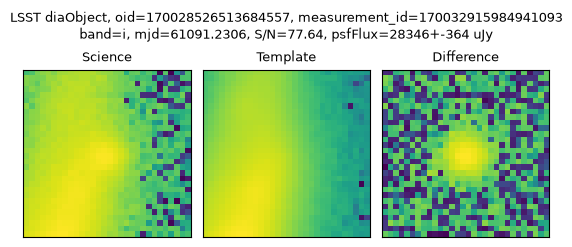

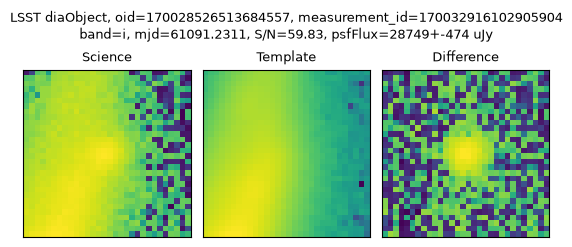

In [41]:
if oid_lsst is not None:
    for i, row_this in df_dets_this.iterrows():
        mask = df_stamps.loc[[i]]['measurement_id'] == row_this['measurement_id']
        obj = df_stamps.loc[[i]][mask]
    
        for i, row in obj.iterrows():
            title = set_title(oid=i, sid=sid_lsst, row=row_this)
            ms.plot_stamps(row, title=title, fontsize=fontsize)

Note that LSST images are not always aligned. We use the header WCS to show stamps including equatorial coordinates. We continue this section showing only stamps for the first detection

In [42]:
if oid_lsst is not None:
    df_dets_this = df_dets_this[~df_dets_this.index.duplicated(keep='first')].copy()
    display(df_dets_this)

,band,mjd,survey_id,ra,dec,measurement_id,parentDiaSourceId,diaObjectId,psfFlux,psfFluxErr,psfFlux_flag,psfFlux_flag_edge,psfFlux_flag_noGoodPixels,scienceFlux,scienceFluxErr,has_stamp,visit,detector,ssObjectId,raErr,decErr,ra_dec_Cov,x,xErr,y,yErr,centroid_flag,apFlux,apFluxErr,apFlux_flag,apFlux_flag_apertureTruncated,isNegative,snr,psfLnL,psfChi2,psfNdata,trailFlux,trailFluxErr,trailRa,trailRaErr,trailDec,trailDecErr,trailLength,trailLengthErr,trailAngle,trailAngleErr,trailChi2,trailNdata,trail_flag_edge,dipoleMeanFlux,dipoleMeanFluxErr,dipoleFluxDiff,dipoleFluxDiffErr,dipoleLength,dipoleAngle,dipoleChi2,dipoleNdata,forced_PsfFlux_flag,forced_PsfFlux_flag_edge,forced_PsfFlux_flag_noGoodPixels,templateFlux,templateFluxErr,ixx,iyy,ixy,ixxPSF,iyyPSF,ixyPSF,shape_flag,shape_flag_no_pixels,shape_flag_not_contained,shape_flag_parent_source,extendedness,reliability,isDipole,dipoleFitAttempted,timeProcessedMjdTai,timeWithdrawnMjdTai,bboxSize,pixelFlags,pixelFlags_bad,pixelFlags_cr,pixelFlags_crCenter,pixelFlags_edge,pixelFlags_nodata,pixelFlags_nodataCenter,pixelFlags_interpolated,pixelFlags_interpolatedCenter,pixelFlags_offimage,pixelFlags_saturated,pixelFlags_saturatedCenter,pixelFlags_suspect,pixelFlags_suspectCenter,pixelFlags_streak,pixelFlags_streakCenter,pixelFlags_injected,pixelFlags_injectedCenter,pixelFlags_injected_template,pixelFlags_injected_templateCenter,glint_trail,band_name
oid,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
170028526513684557,3,61091.230601,lsst,187.02019,6.967834,170032915984941093,0,170028526513684557,28346.492,363.65262,0,0,0,59275.176,366.90543,True,2026021900296,173,0.0,0.000002,0.000003,2.103397e-13,2928.5242,0.04736,1163.9258,0.043955,False,29124.281,824.3923,False,False,False,77.63544,None,1640.1871,1681,26388.596,0.194594,187.02019,None,6.967834,None,0.526794,None,25.376963,None,None,0,False,None,None,None,None,None,None,None,0,False,False,False,30308.605,38.607933,0.193376,0.17157,0.005048,0.179833,0.170434,-0.000464,False,False,False,False,0.007664,0.999996,False,False,61091.232208,None,26,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,i


We show the header for the Science cutout

In [43]:
if oid_lsst is not None:
    row_this = df_stamps.iloc[0].copy()
    display(row_this['flux_Science_header'])

SIMPLE  =                    T / conforms to FITS standard                      
BITPIX  =                  -32 / array data type                                
NAXIS   =                    2 / number of array dimensions                     
NAXIS1  =                   30                                                  
NAXIS2  =                   30                                                  
EXTEND  =                    T                                                  
CUTMINX =                 2913                                                  
CUTMINY =                 1148                                                  
ROTPA   =     102.844791785031 / Pos angle in deg of focal plane +Y wrt North   
BUNIT   = 'nJy     '                                                            
WCSAXES =                    2 / Number of coordinate axes                      
CRPIX1  =      15.524277890042 / Pixel coordinate of reference point            
CRPIX2  =      15.9258142600

Having the header data, we can plot stamps including WCS axes

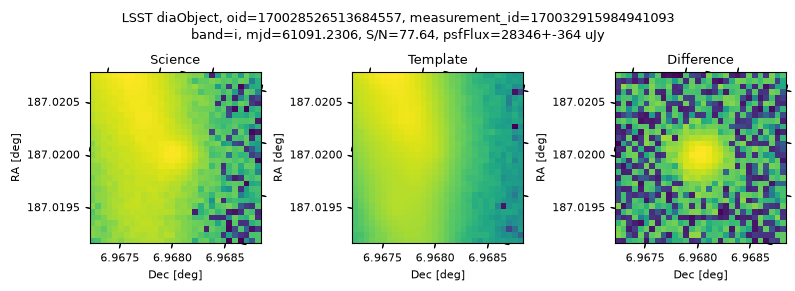

In [44]:
if oid_lsst is not None:
    for j, row_this in df_dets_this.iterrows():
        mask = df_stamps.loc[[j]]['measurement_id'] == row_this['measurement_id']
        obj = df_stamps.loc[[j]][mask]
    
        for i, row in obj.iterrows():
            title = set_title(oid=i, sid=sid_lsst, row=row_this)
            ms.plot_stamps(row, title=title, fontsize=fontsize,
                           use_wcs=True, figsize=[8, 8], title_offset=0.68)

The client function ```get_stamps``` also allows to retrieve additional planes included in LSST stamps, i.e. variance and PSF. We can compute the image shape of each plane and cutout type

In [45]:
if oid_lsst is not None:
    include_variance_and_psf = True

    df_stamps = ms.query_stamps(
        client=alerce_client,
        df_objs=df_dets_this,
        survey='lsst',
        sid=sid_lsst,
        include_variance_and_psf=include_variance_and_psf
    )
    print(df_stamps.columns)

Index(['measurement_id', 'flux_Science_data', 'flux_Science_header',
       'flux_Template_data', 'flux_Template_header', 'flux_Difference_data',
       'flux_Difference_header', 'variance_Science_data',
       'variance_Science_header', 'variance_Template_data',
       'variance_Template_header', 'variance_Difference_data',
       'variance_Difference_header', 'psf_Science_data', 'psf_Science_header',
       'psf_Template_data', 'psf_Template_header', 'psf_Difference_data',
       'psf_Difference_header'],
      dtype='object')


In [46]:
if oid_lsst is not None:
    cols = []
    for plane in ms.image_planes:
        cols += [plane + '_' + x + '_data' for x in ms.image_subtypes]
    #print(cols)

    for col in cols:
        df_stamps[col.replace('data', 'shape')] = [x.shape for x in df_stamps[col]]
    display(df_stamps[['measurement_id'] + [x.replace('data', 'shape') for x in cols]])

,measurement_id,flux_Science_shape,flux_Template_shape,flux_Difference_shape,variance_Science_shape,variance_Template_shape,variance_Difference_shape,psf_Science_shape,psf_Template_shape,psf_Difference_shape
oid,,,,,,,,,,
170028526513684557,170032915984941093,"(30, 30)","(30, 30)","(30, 30)","(30, 30)","(30, 30)","(30, 30)","(41, 41)","(47, 47)","(41, 41)"


We plot all planes for the stamps shown above

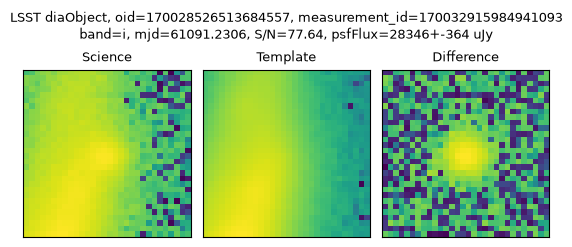

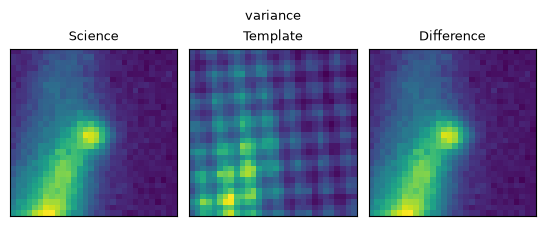

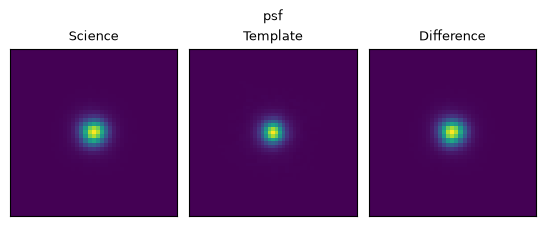

In [47]:
if oid_lsst is not None:
    for j, row_this in df_dets_this.iterrows():
        mask = df_stamps.loc[[j]]['measurement_id'] == row_this['measurement_id']
        obj = df_stamps.loc[[j]][mask]
    
        for i, row in obj.iterrows():
            title = set_title(oid=i, sid=sid_lsst, row=row_this)
            for plane in ms.image_planes:
                title_aux = title if plane == 'flux' else plane
                title_offset = 0.72 if plane == 'flux' else 0.7
                ms.plot_stamps(row, plane=plane, title=title_aux,
                               fontsize=fontsize, title_offset=title_offset)

#### ZTF stamps <a class='anchor' id='stamps_ztf'></a>

We show alert image cutouts for the first detection of this object that triggered ZTF alerts, using the ```has_stamp``` as before

In [48]:
if oid_ztf is not None:
    mask = epochs_ztf['detections']['has_stamp']
    df_dets_this = epochs_ztf['detections'][mask].sort_values(by='mjd').iloc[[0]].copy()

    cols = ['candid', 'band', 'mjd',
            'magpsf', 'sigmapsf', 'magpsf_corr', 'sigmapsf_corr_ext',
            'fluxdiff_nJy', 'fluxdiff_err_nJy', 'fluxsci_nJy', 'fluxsci_err_nJy',
            'has_stamp']
    display(df_dets_this)#[cols])

,tid,mjd,candid,fid,pid,diffmaglim,isdiffpos,nid,distnr,magpsf,magap,sigmapsf,sigmagap,ra,dec,rb,rbversion,drb,magapbig,sigmagapbig,rfid,has_stamp,corrected,dubious,step_id_corr,phase,parent_candid,magpsf_corr,sigmapsf_corr,sigmapsf_corr_ext,band,fluxdiff_nJy,fluxdiff_err_nJy,fluxsci_nJy,fluxsci_err_nJy
oid,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
ZTF26aacextk,ztf,61059.56081,3305560815515015025,1,3305560815515,20.492268,1,3305,1.491836,20.141708,20.1365,0.183754,0.2805,187.020236,6.967859,0.764286,t17_f5_c3,0.999971,20.1899,0.3743,473120155.0,True,False,False,27.5.7a32.dev1,0.0,NaN,NaN,NaN,NaN,g,31865.211105,5392.97735,NaN,NaN


We retrieve the stamps, obtaining the main fields: Science, Template and Difference

In [49]:
if oid_ztf is not None:
    for i, row in df_dets_this.iterrows():
        params = {
            'survey': 'ztf',
            'oid': i,
            'measurement_id': row['candid'],
        }
        df_stamps = alerce_client.plot_stamps(**params)

We show the same stamps, but using the custom function defined in ```alerce_multisurvey_tools.py```

In [50]:
if oid_ztf is not None:
    df_stamps = ms.query_stamps(client=alerce_client, df_objs=df_dets_this,
                                survey='ztf', sid=sid_ztf)
    print(df_stamps.columns)

Index(['candid', 'flux_Science_data', 'flux_Science_header',
       'flux_Template_data', 'flux_Template_header', 'flux_Difference_data',
       'flux_Difference_header'],
      dtype='object')


We show how this table looks like for the first detection

In [51]:
if oid_ztf is not None:
    display(df_stamps.iloc[[0]])

,candid,flux_Science_data,flux_Science_header,flux_Template_data,flux_Template_header,flux_Difference_data,flux_Difference_header
oid,,,,,,,
ZTF26aacextk,3305560815515015025,"[[153.76085, 148.7677, 154.9373, 140.24065, 149.42482, 137.37659, 143.01779, 140.11407, 141.5549, 142.48053, 143.60275, 149.86731, 137.75809, 148.06216, 143.02255, 135.65848, 143.17496, 149.68933, 144.58127, 159.18661, 148.5791, 148.775, 146.30821, 141.60979, 136.56639, 143.12866, 141.30988, 149.26938, 141.16318, 147.1166, 142.85457, 147.12003, 139.79066, 140.23015, 135.27896, 136.97346, 140.97499, 149.9501, 133.041, 143.85791, 138.72527, 137.86339, 145.5502, 142.54152, 135.20805, 141.50423, 142.93964, 136.971, 143.05826, 139.5149, 141.69563, 138.20801, 142.3014, 148.37863, 149.95348, 144.53914, 145.09537, 139.9565, 138.32625, 147.85597, 144.73973, 151.23886, 154.64067], [140.41394, 138.04576, 136.29495, 146.05074, 147.15555, 139.1397, 151.0476, 142.99701, 147.50378, 142.13565, 148.00989, 141.66257, 143.79913, 136.86316, 136.03635, 144.00534, 136.92911, 137.97208, 142.0292, 133.14932, 136.72174, 145.62305, 146.6186, 144.86195, 143.76422, 143.66873, 135.2901, 145.6656, 139.95477, 13...","[SIMPLE, BITPIX, NAXIS, NAXIS1, NAXIS2, EXTEND, BUNIT, STAMP_TYPE]","[[140.06581, 141.58687, 142.4164, 143.42407, 141.75003, 141.60637, 140.50523, 142.075, 142.35934, 143.28735, 143.93192, 141.096, 143.44272, 142.17432, 142.78487, 140.64351, 141.15245, 142.68327, 142.76382, 143.32849, 140.80238, 139.67706, 141.17587, 143.05147, 144.08232, 143.41055, 143.19472, 143.62448, 141.43384, 142.99217, 142.9618, 142.617, 143.38446, 140.99013, 140.32455, 142.02386, 141.74004, 141.09554, 142.20491, 143.37517, 143.52539, 141.95714, 140.30807, 141.38828, 140.68571, 140.68462, 143.66649, 140.94435, 140.00693, 144.5092, 143.14772, 141.7696, 142.85547, 142.68921, 140.9937, 140.65005, 142.95757, 142.36835, 140.34883, 140.98926, 141.84146, 144.75261, 144.11824], [142.71425, 142.38512, 142.45166, 142.67511, 141.20023, 141.84915, 142.9808, 142.45654, 141.6765, 142.92621, 143.21771, 141.47589, 141.0069, 143.30319, 144.8557, 142.87315, 141.29561, 141.75787, 144.08278, 142.9604, 142.05922, 143.44496, 143.24777, 141.22906, 141.48619, 142.92651, 145.78474, 142.23975, 140.794...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOUNT, GCOUNT, BUNIT, STAMP_TYPE]","[[15.158253, 6.332895, 12.216802, -3.9246356, 7.6587296, -5.7872343, 3.3946004, -3.182397, 1.0284905, -2.3052855, -3.1295397, 8.029535, -6.504027, 3.8452213, -0.52157986, -4.258127, 0.41083288, 4.853099, 0.8524218, 13.891681, 8.555835, 8.002163, 4.6062346, -2.6311789, -7.5777173, -0.5365121, -1.3784057, 4.3826404, -0.07007123, 0.36844164, 2.3982155, 1.6960601, -3.7016284, 0.07144112, -3.6515408, -3.294503, -0.36090598, 9.398489, -8.837204, -0.122667335, -5.0134034, -3.97463, 6.117778, 3.318834, -8.838692, 1.0745775, -0.6715295, -4.3350954, 3.5853126, -5.064873, -4.397941, -3.1372943, -0.86251515, 5.661196, 7.7656746, 5.3095245, 1.4475788, -3.365352, -0.979094, 5.8032756, 3.7401266, 3.289026, 9.174733], [-3.4314396, -4.538858, -7.545135, 4.4898925, 5.889974, -1.6843364, 6.170234, 1.4424549, 3.0405512, 1.1119909, 6.390275, 0.81296366, 3.1074033, -4.575533, -10.173475, 1.3104137, -2.2974424, -4.299433, -0.8694483, -11.533109, -6.6321707, 2.4919965, 3.935188, 4.46761, 3.3733177, 0.9771...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOUNT, GCOUNT, BUNIT, STAMP_TYPE]"


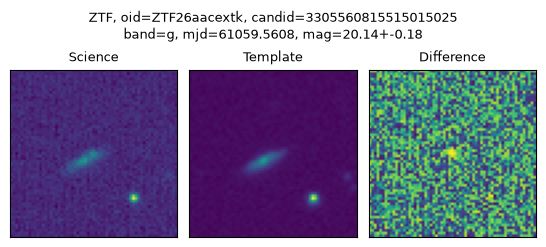

In [52]:
if oid_ztf is not None:
    for i, row_this in df_dets_this.iterrows():
        mask = df_stamps.loc[[i]]['candid'] == row_this['candid']
        obj = df_stamps.loc[[i]][mask]
    
        for i, row in obj.iterrows():
            title = set_title(oid=i, sid=sid_ztf, row=row_this)
            ms.plot_stamps(row, title=title, fontsize=fontsize)

Note that ZTF images have always the same alignment, and that their header does not include WCS (nor do they include extra planes).

### Features <a class='anchor' id='features'></a>

We query the features computed by ALeRCE in each survey using TAP. For LSST, note that we use integer identifiers for both feature names and LSST bands. We recover the original names using the mapping defined in the ```feature_name_lut``` and ```band``` lookup tables (LUTs) respectively. 

In [53]:
table_name = 'feature_name_lut'

query = '''
SELECT
    *
FROM
    alerce_tap.%s
WHERE
    tid = %d
''' % (table_name, tid)
df_feature_names = tap_query(query)

display(df_feature_names)

,feature_id,feature_name,created_date,sid,tid
0,0,u-g_mean,2026-04-16,1,1
1,1,u-g_max,2026-04-16,1,1
2,2,g-r_mean,2026-04-16,1,1
3,3,g-r_max,2026-04-16,1,1
4,4,r-i_mean,2026-04-16,1,1
...,...,...,...,...,...
141,141,z-W4,2026-04-16,1,1
142,142,y-W1,2026-04-16,1,1
143,143,y-W2,2026-04-16,1,1
144,144,y-W3,2026-04-16,1,1


In [54]:
table_name = 'band'

query = '''
SELECT
    sid, tid, band, band_name, band_order
FROM
    alerce_tap.%s
WHERE
    tid = %d
ORDER BY
    sid ASC, band_order ASC
''' % (table_name, tid)

df_bands = tap_query(query)
display(df_bands)

,sid,tid,band,band_name,band_order
0,1,1,6,u,0
1,1,1,1,g,1
2,1,1,2,r,2
3,1,1,3,i,3
4,1,1,4,z,4
5,1,1,5,y,5
6,2,1,6,u,0
7,2,1,1,g,1
8,2,1,2,r,2
9,2,1,3,i,3


In [55]:
if oid_lsst is not None:
    query = '''
    SELECT
        *
    FROM
        alerce_tap.feature
    WHERE
        oid = %d
        AND sid = %d
    ''' % (oid_lsst, sid_lsst)
    df_ft_lsst = tap_query(query)
    
    display(df_ft_lsst)

,oid,sid,feature_id,band,version,feature_value,updated_date
0,170028526513684557,1,2,0,1,1.315352,2026-04-06
1,170028526513684557,1,3,0,1,1.038762,2026-04-06
2,170028526513684557,1,4,0,1,0.219547,2026-04-06
3,170028526513684557,1,5,0,1,0.158628,2026-04-06
4,170028526513684557,1,12,0,1,0.808000,2026-04-06
...,...,...,...,...,...,...,...
258,170028526513684557,1,117,2,1,-0.745273,2026-04-06
259,170028526513684557,1,117,3,1,0.062493,2026-04-06
260,170028526513684557,1,118,1,1,24.136970,2026-04-06
261,170028526513684557,1,118,2,1,22.770606,2026-04-06


We create a function to apply the mapping between columns, useful for both LUTs

In [56]:
def add_mapped_column(df=None, df_lut=None,
                      col=None, col_mapped=None):
    def map_column(row):
        row_index = (row['sid'], row[col]) \
                    if 'sid' in df_lut.columns \
                    else row[col]
        col_new = df_aux.loc[
            row_index, col_mapped] \
            if row_index in df_aux.index \
            else None
        return col_new
    
    df = df.copy()

    if len(df) > 0:
        row_index = ['sid', col] if 'sid' in df_lut.columns else col
        df_aux = df_lut.set_index(row_index).copy()
        
        df[col_mapped] = df.apply(
            lambda row: map_column(row),
            axis=1)
    else:
        df[col_mapped] = None

    return df

In [57]:
if oid_lsst is not None:
    df_ft_lsst = add_mapped_column(
        df=df_ft_lsst,
        df_lut=df_bands,
       col='band',
        col_mapped='band_name'
    )

In [58]:
if oid_lsst is not None:
    df_ft_lsst = add_mapped_column(
        df=df_ft_lsst,
        df_lut=df_feature_names,
        col='feature_id',
        col_mapped='feature_name'
    )

We show the list of features retrieved (note that features with NaN values are not stored in our multisurvey database)

In [59]:
if oid_lsst is not None:
    pd.set_option('display.max_rows', None)
    display(df_ft_lsst)
    pd.set_option('display.max_rows', 30)

,oid,sid,feature_id,band,version,feature_value,updated_date,band_name,feature_name
0,170028526513684557,1,2,0,1,1.315352e+00,2026-04-06,None,g-r_mean
1,170028526513684557,1,3,0,1,1.038762e+00,2026-04-06,None,g-r_max
2,170028526513684557,1,4,0,1,2.195467e-01,2026-04-06,None,r-i_mean
3,170028526513684557,1,5,0,1,1.586284e-01,2026-04-06,None,r-i_max
4,170028526513684557,1,12,0,1,8.080005e-01,2026-04-06,None,g-r_mean_corr
5,170028526513684557,1,13,0,1,6.920177e-01,2026-04-06,None,g-r_max_corr
6,170028526513684557,1,14,0,1,2.593567e-01,2026-04-06,None,r-i_mean_corr
7,170028526513684557,1,15,0,1,2.432009e-01,2026-04-06,None,r-i_max_corr
8,170028526513684557,1,20,0,1,4.590143e+01,2026-04-06,None,Timespan
9,170028526513684557,1,21,0,1,-9.851729e-01,2026-04-06,None,Coordinate_x


For ZTF, we query features as (note that features with NaN values are still stored in our legacy database)

In [60]:
if oid_ztf is not None:
    query = '''
    SELECT
        *
    FROM
        ztf.feature
    WHERE
        oid = '%s'
    ''' % oid_ztf
    df_ft_ztf = tap_query(query)

    df_ft_ztf = df_ft_ztf.sort_values(
        by=['name', 'fid', 'version']).reset_index().drop(
        columns='index').copy()

    pd.set_option('display.max_rows', None)
    display(df_ft_ztf)
    pd.set_option('display.max_rows', 30)

,oid,name,value,fid,version
0,ZTF26aacextk,Amplitude,NaN,1,27.5.7a32.dev1
1,ZTF26aacextk,Amplitude,NaN,2,27.5.7a32.dev1
2,ZTF26aacextk,AndersonDarling,NaN,1,27.5.7a32.dev1
3,ZTF26aacextk,AndersonDarling,NaN,2,27.5.7a32.dev1
4,ZTF26aacextk,Autocor_length,NaN,1,27.5.7a32.dev1
5,ZTF26aacextk,Autocor_length,NaN,2,27.5.7a32.dev1
6,ZTF26aacextk,Beyond1Std,NaN,1,27.5.7a32.dev1
7,ZTF26aacextk,Beyond1Std,NaN,2,27.5.7a32.dev1
8,ZTF26aacextk,Con,NaN,1,27.5.7a32.dev1
9,ZTF26aacextk,Con,NaN,2,27.5.7a32.dev1
